The video is found [here](https://youtu.be/dqpA3Z86qkI?si=I-8Md2aGPtXze2cv).

# UNets in JAX

A simple implementation of a hierarchical convolutional neural network in JAX;
used to learn a solver to a 1d Poisson equation.

$$ \frac{d^2 u}{dx^2} = - f(x) \qquad u(x=0) = u(x=L) = 0$$

The Poisson equation (together with homogeneous Dirichlet boundary conditions)
maps a force field $f(x)$ to the displacement of thin string $u(x)$.

The UNet $f_\theta$ is trained to map $f(x) \mapsto u(x)$.

### Original UNet schematic by Ronneberger et al. (2015) (our concrete implementation deviates from this):

![unet-schematic.png](unet.png)

In [1]:
import jax
from jax import numpy as jnp
from jax import random as jr
import equinox as eqx
from typing import Callable
import optax
from matplotlib import pyplot as plt
from tqdm.autonotebook import tqdm

/tmp/ipykernel_36915/4028359340.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
plt.style.use("dark_background")

In [3]:
NUM_POINTS = 32
NUM_SAMPLES = 1000
DOMAIN_EXTENT = 5 
grid = jnp.linspace(0, DOMAIN_EXTENT, NUM_POINTS + 2)[1:-1]
dx = grid[1] - grid[0]

A = jnp.diag(jnp.ones(NUM_POINTS-1), -1) - 2 * jnp.diag(jnp.ones(NUM_POINTS), 0) + jnp.diag(jnp.ones(NUM_POINTS-1), 1)
A = A / dx ** 2

def solve_poisson(f):
    return jnp.linalg.solve(A, -f)

In [6]:
def create_discontinuity(key):
    lower_key, upper_key = jr.split(key)
    lower_limit = jr.uniform(lower_key, (), minval=0.2*DOMAIN_EXTENT, maxval=0.4*DOMAIN_EXTENT)
    upper_limit = jr.uniform(lower_key, (), minval=0.6*DOMAIN_EXTENT, maxval=0.8*DOMAIN_EXTENT)
    return jnp.where((grid >= lower_limit) & (grid <= upper_limit), 1.0, 0.0)

In [7]:
primary_key = jr.key(0)
keys = jr.split(primary_key, NUM_SAMPLES)
force_fields = jax.vmap(create_discontinuity)(keys)
displacement_fields = jax.vmap(solve_poisson)(force_fields)

In [9]:
force_fields.shape, displacement_fields.shape

((1000, 32), (1000, 32))

In [10]:
force_fields = force_fields[:, None, :]
displacement_fields = displacement_fields[:, None, :]
force_fields.shape, displacement_fields.shape

((1000, 1, 32), (1000, 1, 32))

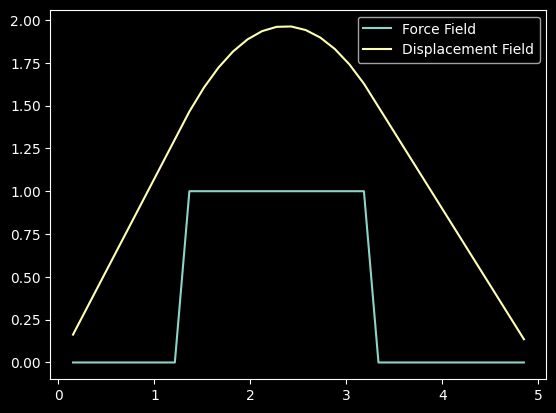

In [11]:
plt.plot(grid, force_fields[0, 0], label="Force Field")
plt.plot(grid, displacement_fields[0, 0], label="Displacement Field")
plt.legend();

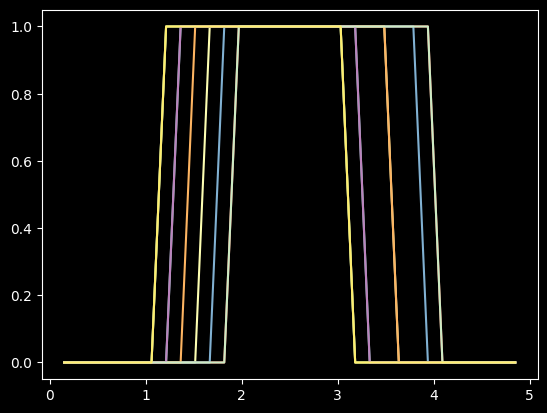

In [12]:
plt.plot(grid, force_fields[:10, 0].T, label="Force Fields")

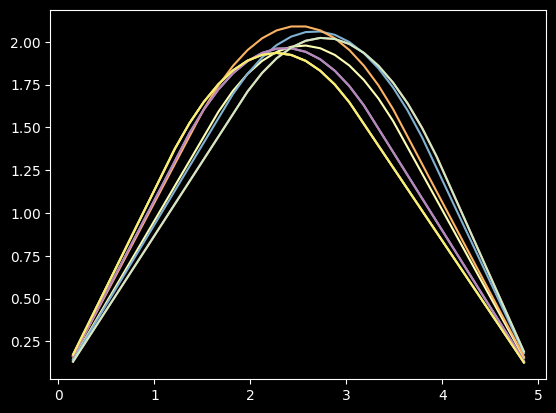

In [13]:
plt.plot(grid, displacement_fields[:10, 0].T, label="Displacement Fields")

In [14]:
split_index = NUM_SAMPLES * 4 // 5
train_x, test_x = force_fields[:split_index], force_fields[split_index:]
train_y, test_y = displacement_fields[:split_index], displacement_fields[split_index:]

In [15]:
train_x.shape, train_y.shape

((800, 1, 32), (800, 1, 32))

In [16]:
test_x.shape, test_y.shape

((200, 1, 32), (200, 1, 32))

## U-Net Implementation

In [ ]:
class DoubleConv(eqx.Module):
    conv_1: eqx.nn.Conv
    conv_2: eqx.nn.Conv
    activation: Callable

    def __init__(
        self,
        num_spatial_dims: int, 
        in_channels: int,
        out_channels: int,
        activation: Callable,
        *,
        key
    ):
        c_1_key, c_2_key = jr.split(key)
        self.conv_1 = eqx.nn.Conv(
            num_spatial_dims=num_spatial_dims,
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            key=c_1_key,
        )
        self.conv_2 = eqx.nn.Conv(
            num_spatial_dims=num_spatial_dims,
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            padding=1,
            key=c_2_key,
        )        
        self.activation = activation
    
    def __call__(self, x: jax.Array):
        x = self.conv_1(x)
        x = self.activation(x)
        x = self.conv_2(x)
        return self.activation(x)

In [25]:
class UNet(eqx.Module):
    lifting: DoubleConv
    down_sampling_blocks: list[eqx.nn.Conv]
    left_arc_blocks: list[DoubleConv]
    right_arc_blocks: list[DoubleConv]
    up_sampling_blocks: list[eqx.nn.Conv]
    projection: eqx.nn.Conv

    def __init__(
        self,
        num_spatial_dims: int,
        in_channels: int,
        out_channels: int,
        hidden_channels: int,
        num_levels: int,
        activation: Callable,
        *,
        key,
    ):
        key, lifting_key, projection_key = jr.split(key, 3)
        self.lifting = DoubleConv(
            num_spatial_dims=num_spatial_dims,
            in_channels=in_channels,
            out_channels=hidden_channels,
            activation=activation,
            key=lifting_key,
        )
        self.projection = eqx.nn.Conv(
            num_spatial_dims=num_spatial_dims,
            in_channels=hidden_channels,
            out_channels=out_channels,
            kernel_size=1,
            key=projection_key,
        )

        channel_list = [hidden_channels * 2 ** i for i in range(0, num_levels+1)]

        self.down_sampling_blocks = []
        self.left_arc_blocks = []
        self.right_arc_blocks = []
        self.up_sampling_blocks = []

        for (upper_level_channels, lower_level_channels) in zip(channel_list[:-1], channel_list[1:]):
            key, down_key, left_key, up_key, right_key = jr.split(key, 5)
            self.down_sampling_blocks.append(
                eqx.nn.Conv(
                    num_spatial_dims=num_spatial_dims,
                    in_channels=upper_level_channels,
                    out_channels=upper_level_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    key=down_key,
                )
            )
            self.left_arc_blocks.append(
                DoubleConv(
                    num_spatial_dims=num_spatial_dims,
                    in_channels=upper_level_channels,
                    out_channels=lower_level_channels,
                    activation=activation,
                    key=left_key,
                )
            )
            self.up_sampling_blocks.append(
                eqx.nn.ConvTranspose(
                    num_spatial_dims=num_spatial_dims,
                    in_channels=lower_level_channels,
                    out_channels=upper_level_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                    key=up_key,
                )
            )
            self.right_arc_blocks.append(
                DoubleConv(
                    num_spatial_dims=num_spatial_dims,
                    in_channels=lower_level_channels,
                    out_channels=upper_level_channels,
                    activation=activation,
                    key=right_key,
                )
            )

    def __call__(self, x: jax.Array):
        x = self.lifting(x)
        x_skip = []

        # Left part (contracting path)
        for down, left in zip(self.down_sampling_blocks, self.left_arc_blocks):
            x_skip.append(x)
            x = down(x)
            x = left(x)

        # Right part (expanding path)
        for up, right in zip(reversed(self.up_sampling_blocks), reversed(self.right_arc_blocks)):
            x = up(x)
            x = jnp.concatenate([x, x_skip.pop()], axis=0)
            x = right(x)

        x = self.projection(x)
        return x

In [26]:
poisson_solver_unet = UNet(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    hidden_channels=32,
    num_levels=2,
    activation=jax.nn.relu,
    key=jr.key(0),
)

In [28]:
jax.vmap(poisson_solver_unet)(train_x).shape

(800, 1, 32)